In [1]:
import torch 
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import math
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Define the execution device dynamically
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
dataset = './dataset/jena_climate_2009_2016.csv'
train_size = 0.65
val_size = 0.80
batch_size = 64
seq_len = 72
output_len = 12
d_model = 128 
d_ff = 64
no_of_encoder_layers = 2
no_of_heads = 4
input_features = 14

In [4]:
# Reading data from csv file
df = pd.read_csv(dataset)
df = df.drop(columns = "Date Time")
df = df.groupby(df.index // 6).mean()
data = df.to_numpy()

# Splitting data into train, val, test datasets
data_len = len(data)

train_data = data[0:int(train_size*data_len)]
val_data = data[int(train_size*data_len):int(val_size*data_len)]
test_data = data[int(val_size*data_len)::]

scalar = StandardScaler()
train_data = scalar.fit_transform(train_data)
val_data = scalar.transform(val_data)
test_data = scalar.transform(test_data)

In [5]:
# Creating a custom Dataset class for our usecase
class JenaClimateData(Dataset):
    def __init__(self, dataset, seq_len, output_len):
        self.dataset = dataset
        self.seq_len = seq_len
        self.output_len = output_len
    def __getitem__(self, idx):
        X = self.dataset[idx:idx+self.seq_len, :]
        y = self.dataset[idx+self.seq_len:idx+self.seq_len+self.output_len, 0]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.dataset)-self.seq_len-self.output_len+1

In [6]:
train_dataset = JenaClimateData(train_data, seq_len, output_len)
val_dataset = JenaClimateData(val_data, seq_len, output_len)
test_dataset = JenaClimateData(test_data, seq_len, output_len)

# Creating DataLoader Objects of batch size 64
train_dl = DataLoader(train_dataset, batch_size=batch_size)
val_dl = DataLoader(val_dataset, batch_size=batch_size)
test_dl = DataLoader(test_dataset, batch_size=batch_size)

## Transformer 
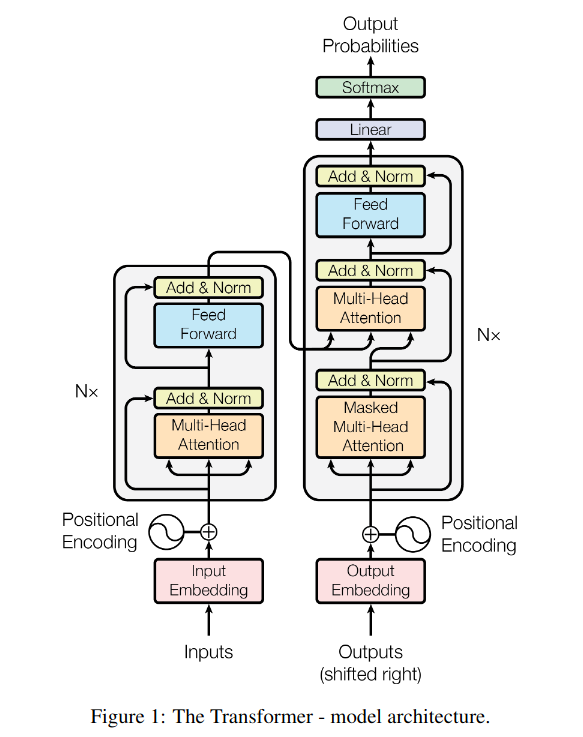

### Input Projection
```
Every timestep contains Temperature, Humidity, Pressure, etc (14 features).
We must convert 14 features into 128-dimensional embedding
Like word embeddings.
```

In [7]:
class InputProjection(nn.Module):
    def __init__(self, input_features, d_model):
        super().__init__()
        self.projection = nn.Linear(input_features, d_model)
    def forward(self, x):
        x = self.projection(x)
        return x

## Sinusoidal Encoding
```text
Our transformer has no reccurence so we inject some information about the relative or absolute positions to the input embeddings
Positional Encoding have the same dimension as the embeddings.
We use sin and cos to provide independent signals at same frequency to make model infer relative position differences
```

In [43]:
class SinusoidalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()

        pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-torch.log(torch.tensor(10000.0)) / d_model)
        )

        pe = torch.zeros(max_len, d_model)

        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)

        pe = pe.unsqueeze(0)

        # register_buffer stores the non-trainable parameters also can be moved to GPU. 
        # Saved along with other parameters
        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

## Multi-Head Attention 
```
We divide the dimensions of the model into multiple heads. We compute the scaled dot-product attentions of the heads in parallel. 

Concatenate the heads along features. This is just a concatenation, this doesnt help relating multiple features so we use a Fully Connected Layer to capture the relationships between all features.

Why Scaled dot-product attention ?
Prevent very large dot products that make the softmax saturate and gradients become small.

```

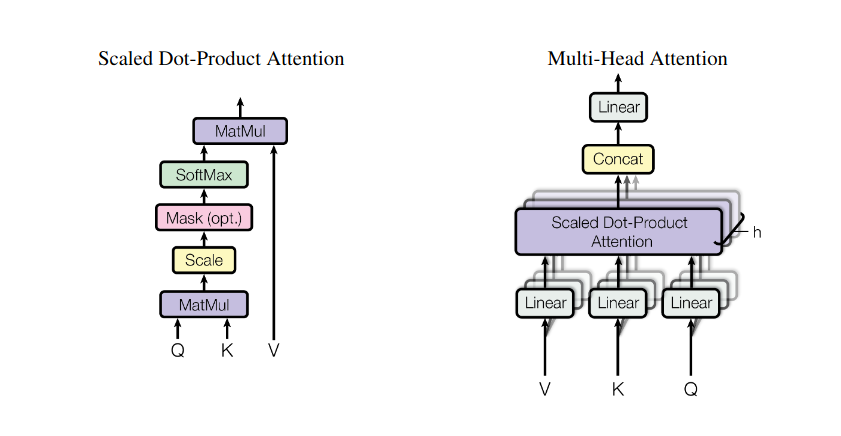

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, no_of_heads):
        super().__init__()
        self.d_model = d_model
        self.no_of_heads = no_of_heads
        self.head_dim = d_model//no_of_heads

        # Weights shape is d_model x d_model
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        # (batch_size, seq_len, d_model)
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        Q = Q.view(        # (batch_size, num_heads, seq_len, head_dim)
            batch_size,
            seq_len,
            self.no_of_heads,
            self.head_dim
        ).transpose(1, 2)
        
        
        K = K.view(        # (batch_size, num_heads, seq_len, head_dim)
            batch_size,
            seq_len,
            self.no_of_heads,
            self.head_dim
        ).transpose(1, 2)
        
        
        V = V.view(        # (batch_size, num_heads, seq_len, head_dim)
            batch_size,
            seq_len,
            self.no_of_heads,
            self.head_dim
        ).transpose(1, 2)
        

        ### MATMUL ###
        scores = torch.matmul(
            Q,                      # (batch_size, num_heads, seq_len, head_dim)
            K.transpose(-2, -1)     # (batch_size, num_heads, head_dim, seq_len)
        )
        
    
        ### SCALE ###
        scores = scores / math.sqrt(self.head_dim) # (batch_size, num_heads, seq_len, seq_len)


        ### SOFTMAX ###
        attention = torch.softmax(scores, dim=-1)
        
        ### MATMUL ###
        output = torch.matmul(
            attention,              # (batch_size, num_heads, seq_len, seq_len)
            V                       # (batch_size, num_heads, seq_len, head_dim)
        )                           # (batch_size, num_heads, seq_len, head_dim)

        ### CONCAT ###
        output = output.transpose(1, 2).contiguous() # (batch_size, seq_len, num_heads, head_dim)
        
        output = output.view(batch_size, seq_len, self.d_model) # (batch_size, seq_len, d_model)

        ### LINEAR ###
        output = self.fc(output)

        return output

## Positionwise Feed forward Network
```
Everything until here are Linear Operations only. Without adding non-linear functions the model cannot learn complex non-linear 
relationships. FFN introduces non-linearity. 

In [10]:
class PositionwiseFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(0.1), nn.Linear(d_ff, d_model))

    def forward(self, x):
        x = self.ffn(x)
        return x

## Encoder Block 
```
Combining all components like MultiHead Attention, Position-wise FFN and Add & Norm.
As specified in the Model Architecture
```

In [11]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, ff_dim, num_head):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, no_of_heads)
        self.ffn = PositionwiseFFN(d_model, d_ff)

        self.dropout1 = nn.Dropout(0.1)
        self.dropout2 = nn.Dropout(0.15)

        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        a = self.attention(x)
        x = x + self.dropout1(a)
        x = self.layernorm1(x)
        ff_output = self.ffn(x)
        x = self.dropout2(ff_output) + x
        x = self.layernorm2(x)
        return x

## Encoder-only Transformer Architecture

```
We combined the input embedding ( projected embeddings), postional encoders and stack of multiple encoder blocks.
It returns the context-aware embeddings

In [12]:
class Transformer(nn.Module):
    def __init__(self, d_model, input_features, max_len, num_layers, output_dim):
        super().__init__()
        self.input_embedding = InputProjection(input_features, d_model)
        self.position_encoding = SinusoidalEncoding(max_len, d_model) 
        self.encoder_blocks = nn.ModuleList([ EncoderBlock(d_model, d_ff, no_of_heads) for _ in range(num_layers) ])

        self.head = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.input_embedding(x)
        x = self.position_encoding(x)
        for encoder in self.encoder_blocks:
            x = encoder(x)

        x = x.mean(dim=1)
        x = self.head(x)

        return x

In [13]:
model = Transformer(d_model, input_features, seq_len, no_of_encoder_layers, output_len)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4, 
    weight_decay=1e-4
)
epochs = 200

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [15]:
def validate_model(model, dl, criterion):
    running_loss = 0
    model.eval()
    
    with torch.no_grad():
        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
    
            y_hat = model(X)
            loss = criterion(y_hat, y)
    
            running_loss += loss.item()

    return running_loss/len(dl)

In [16]:
def evaluate_metrics (model, optimizer, dl):
    huber_loss_function = nn.HuberLoss()
    mae_loss_function = nn.L1Loss()
    mse_loss_function = nn.MSELoss()

    predictions = []
    targets = []
    
    model.eval()
    
    running_huber_loss = 0
    running_mae_loss = 0
    running_mse_loss = 0
    
    with torch.no_grad():
        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
            
            y_hat = model(X)
    
            predictions.append(y_hat.cpu().numpy())
            targets.append(y.cpu().numpy())
    
            running_huber_loss += huber_loss_function(y_hat, y).item()
            running_mae_loss += mae_loss_function(y_hat, y).item()
            running_mse_loss += mse_loss_function(y_hat, y).item()

    y_true = np.concatenate(targets, axis=0)
    y_pred = np.concatenate(predictions, axis=0)

    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - rss / tss
    
    loss_huber = running_huber_loss/len(dl)
    loss_mae = running_mae_loss/len(dl)
    loss_mse = running_mse_loss/len(dl)
    
    return r2, loss_mae, loss_huber, loss_mse, y_true, y_pred

In [17]:
def train_model(model, train_dl, val_dl, criterion, optimizer, epochs):
    val_loss = []
    train_loss = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for X, y in train_dl:
            X = X.to(device)
            y = y.to(device)
        
            optimizer.zero_grad()
            
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
        
            running_loss += loss.item()
            
            optimizer.step()
            
        cur_val_loss = validate_model(model, val_dl, criterion)
        val_loss.append(cur_val_loss)
        scheduler.step(cur_val_loss)

        cur_train_loss = running_loss/len(train_dl)
        train_loss.append(cur_train_loss)
        
        print("EPOCH", epoch, "|" , "Validation Loss", cur_val_loss, "|", "Training Loss", cur_train_loss)
    return val_loss, train_loss
    

In [18]:
val_losses, train_losses = train_model(model, train_dl, val_dl, criterion, optimizer, epochs)

EPOCH 0 | Validation Loss 0.17119563710333013 | Training Loss 0.43812249493346395
EPOCH 1 | Validation Loss 0.12093978671162772 | Training Loss 0.1397061919801346
EPOCH 2 | Validation Loss 0.10557862774017582 | Training Loss 0.1024934716336691
EPOCH 3 | Validation Loss 0.0967491742429192 | Training Loss 0.08792090498083881
EPOCH 4 | Validation Loss 0.08949447734041448 | Training Loss 0.0790457618979504
EPOCH 5 | Validation Loss 0.09011260217821306 | Training Loss 0.07253763352883599
EPOCH 6 | Validation Loss 0.08406652286763024 | Training Loss 0.06861813357767928
EPOCH 7 | Validation Loss 0.07939130732321117 | Training Loss 0.06515349773297141
EPOCH 8 | Validation Loss 0.07603237729953842 | Training Loss 0.06293116170918221
EPOCH 9 | Validation Loss 0.07386446151699573 | Training Loss 0.0609788422973148
EPOCH 10 | Validation Loss 0.07259055749838886 | Training Loss 0.05987387412042998
EPOCH 11 | Validation Loss 0.07013411062878151 | Training Loss 0.05875527174912823
EPOCH 12 | Validati

In [20]:
r2, mae, huber, mse, y_true, y_pred = evaluate_metrics(model, optimizer, test_dl)

In [21]:
print("="*5, "R2 Score", r2, "-", "MAE", mae, "MSE", mse, "Huber", huber, "="*5)

===== R2 Score 0.9563613012433052 - MAE 0.13362001574709328 MSE 0.04117337141160366 Huber 0.02041660119467543 =====


In [38]:
def loss_curves(train_losses, val_losses):
    epochs = range(1, len(train_losses)+1)
    
    plt.figure(figsize=(8,5))

    plt.plot(epochs, train_losses, label="Training Loss", linestyle='--', marker='.', color="red")
    plt.plot(epochs, val_losses, label="Validation Loss", linestyle='-', marker='.', color="blue")
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

In [39]:
def visualization(y, y_hat):
    no_of_y = range(len(y))

    plt.figure(figsize=(12,5))

    plt.plot(y_true[:, 0], label="Ground Truth", color="blue")
    plt.plot(y_pred[:, 0], label="Prediction", color="green")
    
    plt.legend()
    plt.grid(True)

    plt.title("Y and Yhat")
    plt.legend()

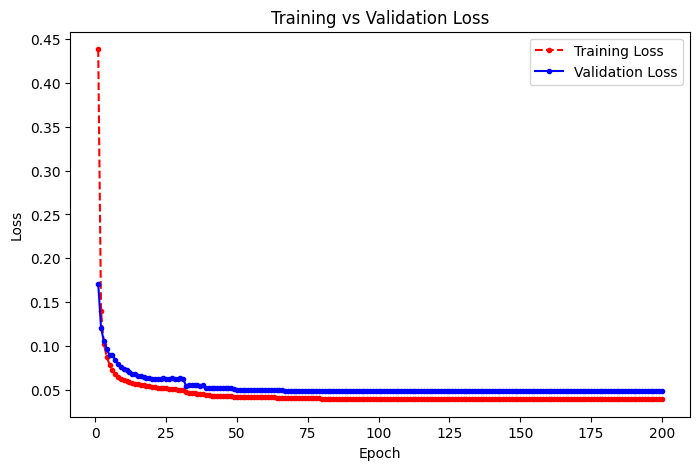

In [40]:
loss_curves(train_losses, val_losses)

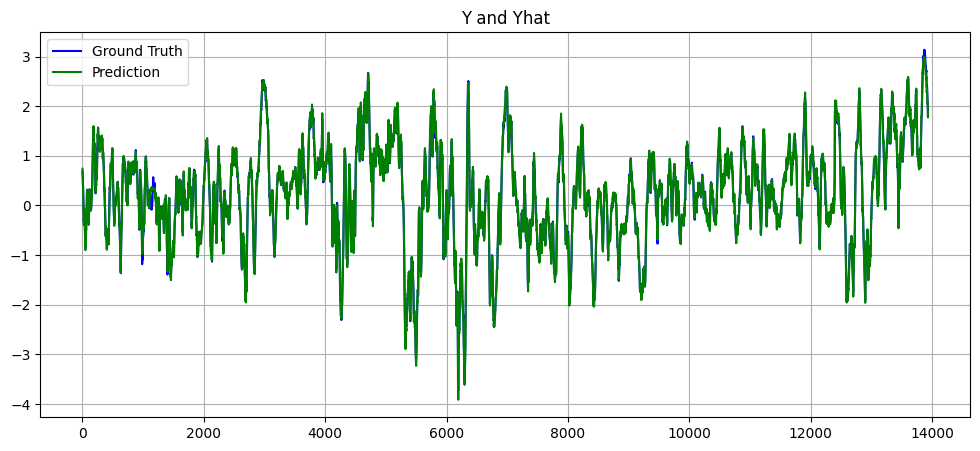

In [41]:
visualization(y_true, y_pred)

In [42]:
torch.save(model.state_dict(), "Transformer_model.pth")